In [1]:
import sys
import os

def get_FGCE_Directory():
    """Get the path of the 'FGCE-Feasible-Group-Counterfactual-Explanations-for-Auditing-Fairness' directory."""
    current_dir = os.getcwd()
    while os.path.basename(current_dir) != 'FGCE-Feasible-Group-Counterfactual-Explanations-for-Auditing-Fairness':
        current_dir = os.path.dirname(current_dir)
        if current_dir == os.path.dirname(current_dir):
            return None
    return current_dir
FGCE_DIR = get_FGCE_Directory()

sys.path.append(FGCE_DIR)
def get_path_separator():
    """Get the system-specific directory separator."""
    return os.sep

sep = get_path_separator()
sys.path.append(FGCE_DIR + f'{sep}src')
sys.path.append(FGCE_DIR + f'{sep}baselines')

# Comparison with AReS approach 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import os
import tensorflow as tf
from ares import Apriori, TwoLevelRecourseSet, AReS
from baselines.dataset import dataset_loader
from FGCE import *
from kernel import *
import Feasibility
from sklearn import preprocessing
import time
from tqdm import tqdm
import warnings
import os
import json
import math
import pickle as pk
import utils
from utils import GraphBuilder
def bold(string):
    return '\033[1m' + string + '\033[0m'
warnings.filterwarnings("ignore")

2025-02-24 12:28:25.878569: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-24 12:28:25.878603: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-24 12:28:25.878630: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-24 12:28:25.884782: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-24 12:28:26.578514: W tensorflow/compiler/

In [3]:
import os
import pandas as pd
import pickle as pk
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

baseline_method = "AReS"
datasetName = 'GermanCredit'
group_identifier = "sex"
classifier = "xgb"

dataset = dataset_loader(datasetName, dropped_features=[], n_bins=None)

# X = dataset.data.iloc[:, :-1]
# y = dataset.data.iloc[:, -1]
FEATURE_COLUMNS = list(dataset.data.columns[:-1])
print(FEATURE_COLUMNS)
TARGET_COLUMNS = dataset.data.iloc[:, -1]
x_train, y_train, x_test, y_test, x_means, x_std = dataset.get_split(
    normalise=False, shuffle=False, return_mean_std=True
)

x_train = pd.DataFrame(x_train, columns=FEATURE_COLUMNS, index=dataset.data.index[:len(x_train)])
x_test = pd.DataFrame(x_test, columns=FEATURE_COLUMNS, index=dataset.data.index[len(x_train):])

print(f"Number of samples in x_test: {len(x_test)}")
print(f"Number of samples in y_test: {len(y_test)}")

model_save_path = f"{FGCE_DIR}{os.sep}tmp{os.sep}baselines{os.sep}{baseline_method}{os.sep}{datasetName}{os.sep}"
os.makedirs(model_save_path, exist_ok=True)
model_file = model_save_path + "XGB_classifier_data.pk"

if os.path.exists(model_file):
    print("Loading existing classifier from file...")
    model = pk.load(open(model_file, "rb"))
else:
    param_grid = {
        'n_estimators': [50, 100, 200, 500],
        'max_depth': [3, 5, 7, 10, 15],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.5, 0.7, 0.9, 1],
        'colsample_bytree': [0.5, 0.7, 0.9, 1],
        'gamma': [0, 0.1, 0.5, 1, 5],
        'reg_alpha': [0, 0.01, 0.1, 1],
        'reg_lambda': [1, 5, 10],
    }
    model = xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=15,
        cv=cv,
        scoring='accuracy',
        n_jobs=2,
        verbose=0,
        random_state=42
    )

    random_search.fit(x_train, y_train)
    model = random_search.best_estimator_

    print(f"\nBest {classifier} Hyperparameters: {random_search.best_params_}")
    print(f"Best cross-validated accuracy: {random_search.best_score_:.4f}")
    print(f"Training Accuracy: {model.score(x_train, y_train):.4f}")
    print(f"Testing Accuracy: {model.score(x_test, y_test):.4f}")

    # Save the trained model
    with open(model_file, 'wb') as file:
        pk.dump(model, file)

dataset.data = dataset.data.drop_duplicates()

dataset.data = dataset.data.reset_index(drop=True)

x_train, y_train, x_test, y_test, x_means, x_std = dataset.get_split(
    normalise=False, shuffle=False, return_mean_std=True
)
x_train = pd.DataFrame(x_train, columns=FEATURE_COLUMNS, index=dataset.data.index[:len(x_train)])
x_test = pd.DataFrame(x_test, columns=FEATURE_COLUMNS, index=dataset.data.index[len(x_train):])

predictions = model.predict(x_test[FEATURE_COLUMNS])
false_negatives_indices = (predictions == 0) & (y_test == 1)
FN = x_test[false_negatives_indices]

predictions_all = model.predict(dataset.data[FEATURE_COLUMNS])
positives_indices = (predictions_all == 1)
positives = dataset.data[positives_indices]


['Existing-Account-Status = 0', 'Existing-Account-Status = 1', 'Existing-Account-Status = 2', 'Existing-Account-Status = 3', 'Month-Duration', 'Credit-History = 0', 'Credit-History = 1', 'Credit-History = 2', 'Credit-History = 3', 'Credit-History = 4', 'Purpose = 0', 'Purpose = 1', 'Purpose = 2', 'Purpose = 3', 'Purpose = 4', 'Purpose = 5', 'Purpose = 6', 'Purpose = 7', 'Purpose = 8', 'Purpose = 9', 'Credit-Amount', 'Savings-Account = 0', 'Savings-Account = 1', 'Savings-Account = 2', 'Savings-Account = 3', 'Savings-Account = 4', 'Present-Employment = 0', 'Present-Employment = 1', 'Present-Employment = 2', 'Present-Employment = 3', 'Present-Employment = 4', 'Instalment-Rate = 0', 'Instalment-Rate = 1', 'Instalment-Rate = 2', 'Instalment-Rate = 3', 'Sex = 0', 'Sex = 1', 'Guarantors = 0', 'Guarantors = 1', 'Guarantors = 2', 'Residence = 0', 'Residence = 1', 'Residence = 2', 'Residence = 3', 'Property = 0', 'Property = 1', 'Property = 2', 'Property = 3', 'Age', 'Installment = 0', 'Installm

### Generate AReS cfes

Dropping Feature: Sex
Computing Candidate Sets of Conjunctions of Predicates SD and RL
Processing 31824 combinations | Sampling itemset size 6
SD and RL Computed with Lengths 4178 and 4178
Saving Copies of SD and RL as SD_copy and RL_copy
Computing Ground Set of Triples V
Reducing RL
RL Reduced from Size 4178 to 990


100%|██████████| 4178/4178 [00:49<00:00, 84.14it/s]  


Ground Set Computed with Length 966960


4999it [01:01, 81.88it/s] 


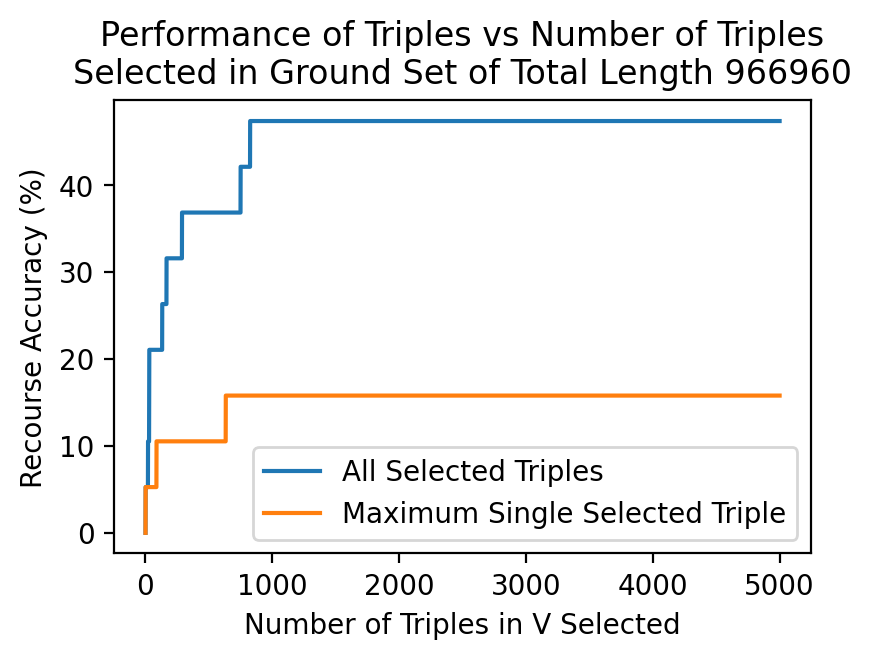

Candidate Set Filtered with Length: 5000
Initialising Copy of Ground Set
While there exists a delete/update operation, loop:
Checking Delete
Checking Add


100%|██████████| 4999/4999 [00:00<00:00, 18244.59it/s]


Checking Exchange


100%|██████████| 4993/4993 [00:01<00:00, 2593.29it/s]


Checking Delete
Checking Add


100%|██████████| 4993/4993 [00:00<00:00, 18238.92it/s]
6it [00:00, 56.66it/s]


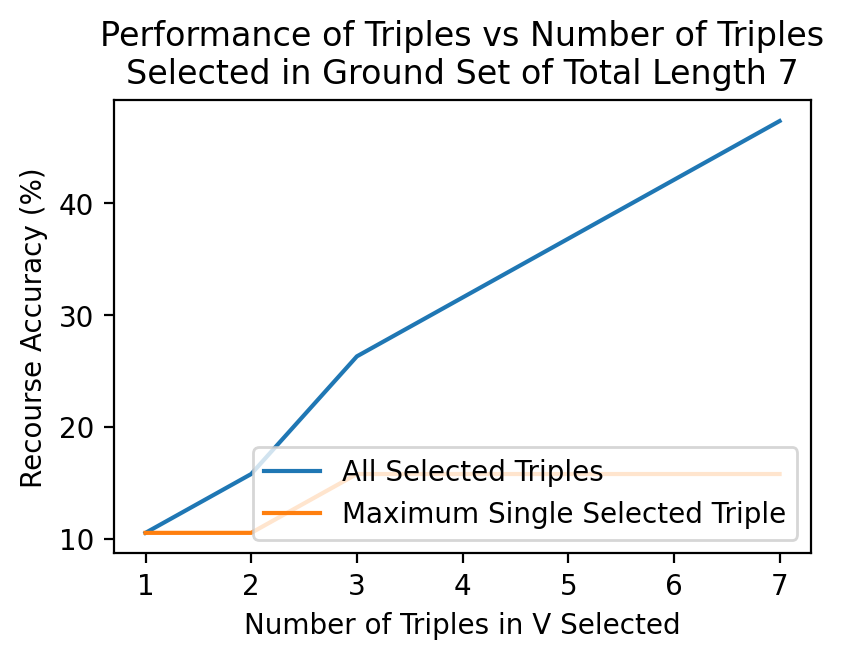

2.664026975631714
Accuracy: 47.37%
Average Cost: 1.11

Accuracy Upper Bound (Evaluated/Sorted Ground Set): 47.37%
Final Triples Post-Optimisation

If Guarantors = 0, Job = 2, Num-People = 0, Savings-Account = 1
	  If Existing-Credits = 1, Foreign-Worker = 0
	Then Existing-Credits = 0, Foreign-Worker = 0

If Housing = 1, Num-People = 0, Savings-Account = 1
	  If Foreign-Worker = 0, Residence = 3
	Then Foreign-Worker = 0, Residence = 2

If Foreign-Worker = 0, Installment = 2, Num-People = 0, Purpose = 4
	  If Marital-Status = 1, Telephone = 0
	Then Marital-Status = 3, Telephone = 1

If Credit-Amount = (636.795, 2172.5], Installment = 2, Marital-Status = 1
	  If Telephone = 0
	Then Telephone = 1

If Residence = 3, Savings-Account = 1, Telephone = 1
	  If Foreign-Worker = 0, Guarantors = 0, Job = 3
	Then Foreign-Worker = 0, Guarantors = 0, Job = 2

If Existing-Account-Status = 1, Guarantors = 0, Housing = 1
	  If Foreign-Worker = 0, Installment = 2, Purpose = 0
	Then Foreign-Worker = 0, In

In [40]:
ares = AReS(model=model, dataset=dataset, X=FN, dropped_features=['Sex'],
            n_bins=10, ordinal_features=[], normalise=None,
            constraints=[20,7,10])  
ares.generate_itemsets(apriori_threshold=0.16, max_width=None, # defaults to e2-1
                       affected_subgroup=None, save_copy=True)
ares.generate_groundset(max_width=None, RL_reduction=True,
                        then_generation=None, save_copy=False)
lams = [1, 0]
# save_mode: 1 and 2 correspond to r and r' in the Fast AReS paper
# save_mode: 1 and 2 will overwrite the ground set, 0 will not
# use save_mode=0 alongside plot_accuracy=True first
# to get an idea of how many triples you need to evaluate
ares.evaluate_groundset(lams=lams, r=5000, save_mode=1,
                        disable_tqdm=False, plot_accuracy=True)
ares.select_groundset(s=5000)
start_time = time.time()
ares.optimise_groundset(lams=lams, factor=1, print_updates=False, print_terms=False)
print(time.time() - start_time)

print("Accuracy:" + " {}%".format(round(ares.R.accuracy, 2)))
# only inputs with positive counterfactual predictions
print("Average Cost:" + " {}".format(round(ares.R.average_cost, 2)))

print("\nAccuracy Upper Bound (Evaluated/Sorted Ground Set):"
      + " {}%".format(round(ares.V.accuracy, 2)))

print(bold("Final Triples Post-Optimisation\n"))
for triple in ares.R.triples:
    outer_ifs, inner_ifs, thens = [sorted([j for j in triple[i]]) for i in range(3)]
    print(bold("If") + " {}".format(', '.join(outer_ifs)))
    print(bold("\t  If") + " {}".format(', '.join(inner_ifs)))
    print(bold("\tThen") + " {}\n".format(', '.join(thens)))

num_of_rules = ares.R.correct_matrix.shape[0]
print(f"Number of rules used {num_of_rules}")

In [41]:
covered_instances = np.where(ares.R.cover_matrix.max(axis=0) > 0)[0]

counterfactuals_dict = {}

for instance_idx in covered_instances:
    instance_counterfactuals = []  
    instance_costs = []  
    
    for rule_idx in range(num_of_rules): 
        if ares.R.cover_matrix[rule_idx, instance_idx] == 1:
            counterfactuals = ares.R.cfx_matrix[rule_idx, instance_idx]  
            costs = ares.R.cost_matrix[rule_idx, instance_idx]  
            instance_counterfactuals.append(counterfactuals)
            instance_costs.append(costs)
    if instance_counterfactuals:
        min_cost_idx = np.argmin(instance_costs) 
        selected_counterfactual = instance_counterfactuals[min_cost_idx]  
        counterfactuals_dict[instance_idx] = selected_counterfactual

#Coverage
print(f"Coverage = {len([i for i in ares.R.cover if i != 0]) / len(FN)}")

Coverage = 0.631578947368421


In [5]:
import os
import json

ces_path = f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}CFES{sep}{datasetName}"
json_file_path = f"{ces_path}{sep}cfes.json"

if os.path.exists(json_file_path):
    with open(json_file_path, 'r') as json_file:
        ces_list_values = json.load(json_file)
        ces = {key: value for key, value in ces_list_values.items()}
        print("CFES loaded from file.")
else:
    ces = {str(key): value for key, value in counterfactuals_dict.items()}
    ces_list_values = {key: value.tolist() for key, value in ces.items()}

    os.makedirs(ces_path, exist_ok=True)

    with open(json_file_path, 'w') as json_file:
        json.dump(ces_list_values, json_file, indent=4)
    print("CFES saved to file.")


CFES loaded from file.


# Add AReS cfes into our graph

In [6]:
def bfs(graph, start_node):
    """
    Breadth-first search to find all reachable nodes from the start node.
    """
    visited = set()
    queue = deque([start_node])
    visited.add(start_node)

    while queue:
        node = queue.popleft()
        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

    return visited
def append_ces_to_df(df, ces):
    ces_df = pd.DataFrame.from_dict(ces, orient='index')
    ces_df.columns = df.columns
    ces_start_index = len(df)

  
    df_combined = pd.concat([df, ces_df], axis=0, ignore_index=True)
    return df_combined, ces_start_index
 

updated_df, ces_start_index = append_ces_to_df(dataset.data.iloc[:,:-1], ces)

categorical_columns = ['Existing-Account-Status', 'Savings-Account', 'Present-Employment', 'Instalment-Rate',
                              'Sex', 'Guarantors', 'Residence', 'Property', 'Installment',
                              'Housing', 'Existing-Credits', 'Job', 'Num-People',
                              'Telephone', 'Foreign-Worker']

for category in categorical_columns:
    category_columns = [col for col in updated_df.columns if col.startswith(f'{category} =')]
    if category_columns:
        updated_df[category] = updated_df[category_columns].idxmax(axis=1).str.extract(rf'{category} = (\d+)').astype(int)
        updated_df.drop(category_columns, axis=1, inplace=True)

min_max_scaler = preprocessing.MinMaxScaler()
data_scaled_with_cfes_np = min_max_scaler.fit_transform(updated_df)
data_scaled_with_cfes_df = pd.DataFrame(data_scaled_with_cfes_np, columns=updated_df.columns)

data_scaled_with_cfes_df.rename(columns=lambda x: x.replace("race = ", "race_"), inplace=True)


race_columns = [col for col in data_scaled_with_cfes_df.columns if "race" in col]
new_race_columns = [f"race_{i}" for i in range(len(race_columns))]
print(new_race_columns)
rename_mapping = dict(zip(race_columns, new_race_columns))
data_scaled_with_cfes_df.rename(columns=rename_mapping, inplace=True)


FEATURE_COLUMNS = data_scaled_with_cfes_df.columns

false_negatives_indices = FN.index

[]


### All constraints

In [7]:
import networkx as nx
tp = 0.5
skip_bandwith_calculation=False
bandwith_approch = "mean_scotts_rule"
results = {}
for e in [2.9]:
    e = round(e, 1)
    print(f"Processing epsilon: {e}")
    if  os.path.exists(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances_all_constr.pkl") and os.path.exists(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}Graph_{e}_all_constr.pkl"):
        graph = pk.load(open(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}Graph_{e}_all_constr.pkl", "rb"))
        kernel = Kernel(datasetName, data_scaled_with_cfes_df, skip_bandwith_calculation=skip_bandwith_calculation, bandwith_approch=bandwith_approch)
        kernel.fitKernel(data_scaled_with_cfes_df)
        fgce = FGCE(data_scaled_with_cfes_df, kernel, FEATURE_COLUMNS, TARGET_COLUMNS, e, model)
        fgce.set_graph(graph)

        print("Loading distances from file ...")
        distances = pk.load(open(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances_all_constr.pkl", "rb"))
    else:
        kernel = Kernel(datasetName, data_scaled_with_cfes_np, skip_bandwith_calculation=skip_bandwith_calculation, bandwith_approch=bandwith_approch)
        kernel.fitKernel(data_scaled_with_cfes_np)
        
        fgce = FGCE(data_scaled_with_cfes_df, kernel, FEATURE_COLUMNS, TARGET_COLUMNS, e, model)
        feasibility_constraints = utils.getFeasibilityConstraints(FEATURE_COLUMNS, dataset_name=datasetName)
       

        start_time = time.time()
        dng_obj = GraphBuilder(feasibility_constraints, FEATURE_COLUMNS, data_scaled_with_cfes_np, kernel, exclude_columns=True)
        distances, graph, densities = dng_obj.compute_pairwise_distances_within_subgroups_and_graph(datasetName, data_scaled_with_cfes_df[FEATURE_COLUMNS], e, feasibility_constraints, representation=16)
        end_time = time.time()
        execution_time = end_time - start_time
        print("Distances and graph initialization: ", execution_time, " seconds")

        if not os.path.exists(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}_all_constr"):
            os.makedirs(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}_all_constr")
        
        if not os.path.exists(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Densities{sep}_all_constr"):
            os.makedirs(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Densities_all_constr")

        if not os.path.exists(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances_all_constr.pkl"):
            pk.dump(distances, open(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances_all_constr.pkl", "wb"))

        pk.dump(graph, open(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}Graph_{e}_all_constr.pkl", "wb"))
        pk.dump(densities, open(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Densities_all_constr{sep}Densities_{e}_all_constr.pkl", "wb"))

    try:
        print(f"Max possible distance considered in graph: {np.max([edge[2]['distance'] for edge in graph.edges(data=True)])}")
    except:
        print(f"Max possible distance considered in graph: {0}")

    strongly_connected_components = list(nx.strongly_connected_components(graph))
    weakly_connected_components = list(nx.weakly_connected_components(graph))

    connected_nodes = sum(1 for node, degree in graph.degree() if degree > 0)

    graph_density = nx.density(graph)

    d = {"strongly_connected_components": len(strongly_connected_components), "weakly_connected_components": len(weakly_connected_components),
        "Percentage_of_connected_nodes": (connected_nodes/len(data_scaled_with_cfes_df))*100, "Density": graph_density * 100}
    print(d,"\n")
    results[e] = d

Processing epsilon: 2.9
Get bandwidth for GermanCredit...
Bandwidth: 0.07826637871777187
Fitting kernel...
Loading distances from file ...
Max possible distance considered in graph: 2.8984375
{'strongly_connected_components': 1006, 'weakly_connected_components': 168, 'Percentage_of_connected_nodes': 84.18972332015811, 'Density': 0.3716040549997459} 



### Count paths from FN to cfes in the feasibility graph in case of all constraints used

In [8]:
fn_to_cfe_paths = {}

for i, fn_node in tqdm(enumerate(false_negatives_indices), total=len(false_negatives_indices), desc="Checking FN to CFE Paths"):
    cfe_node = dataset.data.shape[0] + i 
    if fn_node in graph.nodes():
        reachable_nodes = bfs(graph, fn_node)
        fn_to_cfe_paths[fn_node] = cfe_node in reachable_nodes

connected_fns = sum(fn_to_cfe_paths.values())
print(f"Number of connected FNs: {connected_fns} out of {len(false_negatives_indices)}")

if len(false_negatives_indices) > 0:
    connected_percentage = (connected_fns / len(false_negatives_indices)) * 100
else:
    connected_percentage = 0

print(f"Number of connected FNs: {connected_fns} out of {len(false_negatives_indices)} ({connected_percentage:.2f}%)")


Checking FN to CFE Paths: 100%|██████████| 19/19 [00:00<00:00, 106825.44it/s]

Number of connected FNs: 0 out of 19
Number of connected FNs: 0 out of 19 (0.00%)


### None constraint

In [9]:
import networkx as nx
tp = 0.5
skip_bandwith_calculation=False
bandwith_approch = "mean_scotts_rule"
results = {}
for e in [2.9]:
    e = round(e, 1)
    print(f"Processing epsilon: {e}")
    if  os.path.exists(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances.pkl") and os.path.exists(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}Graph_{e}.pkl"):
        graph = pk.load(open(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}Graph_{e}.pkl", "rb"))
        kernel = Kernel(datasetName, data_scaled_with_cfes_df, skip_bandwith_calculation=skip_bandwith_calculation, bandwith_approch=bandwith_approch)
        kernel.fitKernel(data_scaled_with_cfes_df)
        fgce = FGCE(data_scaled_with_cfes_df, kernel, FEATURE_COLUMNS, TARGET_COLUMNS, e, model)
        fgce.set_graph(graph)

        print("Loading distances from file ...")
        distances = pk.load(open(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances.pkl", "rb"))
    else:
        kernel = Kernel(datasetName, data_scaled_with_cfes_np, skip_bandwith_calculation=skip_bandwith_calculation, bandwith_approch=bandwith_approch)
        kernel.fitKernel(data_scaled_with_cfes_np)
        
        fgce = FGCE(data_scaled_with_cfes_df, kernel, FEATURE_COLUMNS, TARGET_COLUMNS, e, model)
        #feasibility_constraints = utils.getFeasibilityConstraints(FEATURE_COLUMNS, dataset_name=datasetName)
        feasibility_constraints_obj = Feasibility.feasibility_consts(FEATURE_COLUMNS)
        feasibility_constraints_obj._feasibility_set = {}
        feasibility_constraints_obj._feature_columns_to_check=[]

        start_time = time.time()
        dng_obj = GraphBuilder(feasibility_constraints_obj, FEATURE_COLUMNS, data_scaled_with_cfes_np, kernel, exclude_columns=True, constraints=False)
        distances, graph, densities = dng_obj.compute_pairwise_distances_within_subgroups_and_graph(datasetName, data_scaled_with_cfes_df[FEATURE_COLUMNS], e, feasibility_constraints_obj, representation=16)
        end_time = time.time()
        execution_time = end_time - start_time
        print("Distances and graph initialization: ", execution_time, " seconds")

        if not os.path.exists(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}"):
            os.makedirs(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}")
        
        if not os.path.exists(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Densities{sep}"):
            os.makedirs(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Densities")

        if not os.path.exists(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances.pkl"):
            pk.dump(distances, open(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances.pkl", "wb"))

        pk.dump(graph, open(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}Graph_{e}.pkl", "wb"))
        pk.dump(densities, open(f"{FGCE_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Densities{sep}Densities_{e}.pkl", "wb"))

    try:
        print(f"Max possible distance considered in graph: {np.max([edge[2]['distance'] for edge in graph.edges(data=True)])}")
    except:
        print(f"Max possible distance considered in graph: {0}")

    strongly_connected_components = list(nx.strongly_connected_components(graph))
    weakly_connected_components = list(nx.weakly_connected_components(graph))

    connected_nodes = sum(1 for node, degree in graph.degree() if degree > 0)

    graph_density = nx.density(graph)

    d = {"strongly_connected_components": len(strongly_connected_components), "weakly_connected_components": len(weakly_connected_components),
        "Percentage_of_connected_nodes": (connected_nodes/len(data_scaled_with_cfes_df))*100, "Density": graph_density * 100}
    print(d,"\n")
    results[e] = d

Processing epsilon: 2.9
Get bandwidth for GermanCredit...
Bandwidth: 0.10422491361539507
Fitting kernel...


Building graph for subgroup...:   0%|          | 0/316 [00:00<?, ?it/s]

Building graph for subgroup...: 100%|██████████| 696/696 [00:31<00:00, 21.86it/s] 


Distances and graph initialization:  39.90230870246887  seconds
Max possible distance considered in graph: 2.8984375
{'strongly_connected_components': 2, 'weakly_connected_components': 2, 'Percentage_of_connected_nodes': 100.0, 'Density': 47.320189379278524} 



### Count paths from FN to cfes in the feasibility graph in case of none constraints used

In [11]:
fn_to_cfe_paths = {}

for i, fn_node in tqdm(enumerate(false_negatives_indices), total=len(false_negatives_indices), desc="Checking FN to CFE Paths"):
    cfe_node = dataset.data.shape[0] + i 
    if fn_node in graph.nodes():
        reachable_nodes = bfs(graph, fn_node)
        fn_to_cfe_paths[fn_node] = cfe_node in reachable_nodes

connected_fns = sum(fn_to_cfe_paths.values())
print(f"Number of connected FNs: {connected_fns} out of {len(false_negatives_indices)}")

if len(false_negatives_indices) > 0:
    connected_percentage = (connected_fns / len(false_negatives_indices)) * 100
else:
    connected_percentage = 0

print(f"Number of connected FNs: {connected_fns} out of {len(false_negatives_indices)} ({connected_percentage:.2f}%)")


Checking FN to CFE Paths: 100%|██████████| 19/19 [00:00<00:00, 109.78it/s]

Number of connected FNs: 8 out of 19
Number of connected FNs: 8 out of 19 (42.11%)
